## Explainable AI and SHAP Values

In machine learning, models such as Random Forests, Gradient Boosting, or Neural Networks often behave like black boxes — they provide accurate predictions but give little insight into why those predictions were made. This lack of transparency makes it difficult to build trust, debug models, or ensure fairness.

Explainable AI (XAI) aims to bridge this gap by providing methods that make machine learning models more interpretable and transparent, without sacrificing performance. Among these methods, SHAP (SHapley Additive exPlanations) has emerged as a powerful and widely used approach.

SHAP values are based on the concept of Shapley values from cooperative game theory. They assign each feature a contribution score that represents how much that feature influenced a particular prediction. Formally, SHAP ensures three key properties:

- Local accuracy: The sum of SHAP values for all features equals the model’s prediction.

- Consistency: If a model changes so that a feature contributes more, its SHAP value will not decrease.

- Additivity: SHAP provides additive feature attributions, making them intuitive and easy to compare.

By using SHAP values, we can:

- Identify the most important features driving predictions.

- Understand individual predictions (local interpretability).

- Gain a global view of feature importance across the dataset.

This makes SHAP an important tool for building trustworthy and transparent machine learning solutions.

In [ ]:
import pickle
import shap
import matplotlib.pyplot as plt

import os, sys
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)

from sklearn.model_selection import train_test_split
from preprocessing import data_preprocessing

import shap

In [2]:
path = root_dir + "/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

data = data_preprocessing(path)

In [3]:
features = list(data.columns[data.columns!="Churn"])
target = ["Churn"]

X = data[features]
y = data[target].values.ravel()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [4]:
features

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'PaperlessBilling',
 'MonthlyCharges',
 'TotalCharges',
 'InternetService_Fiber optic',
 'InternetService_No',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [5]:
# Load the saved model
model = pickle.load(open('model.pkl', 'rb'))

# Create a SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

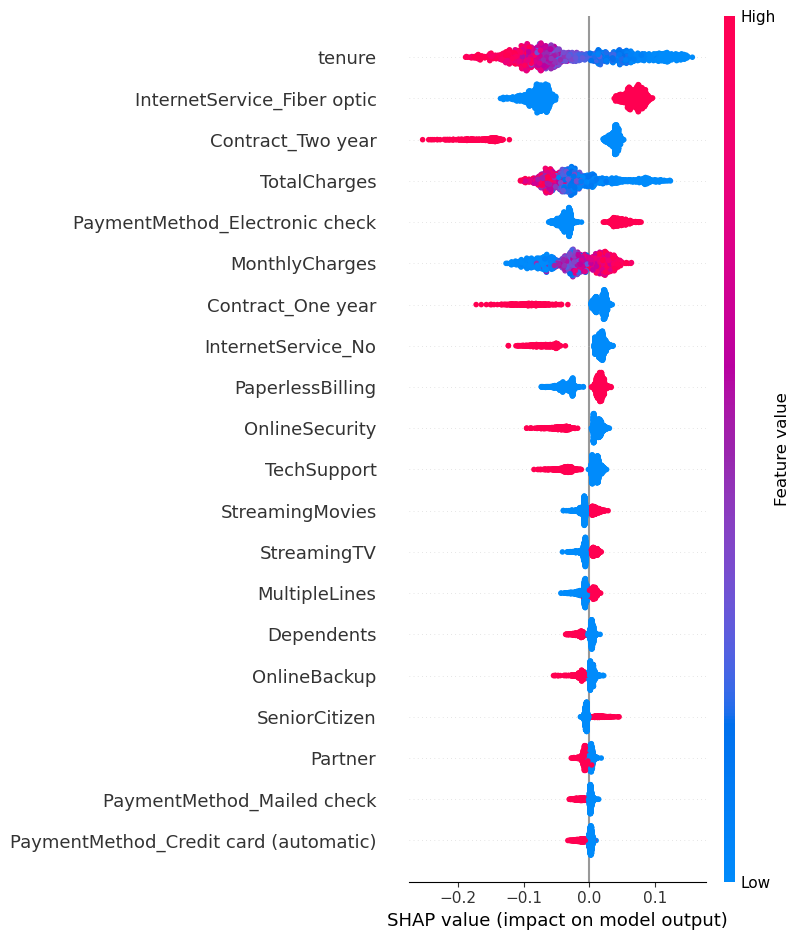

In [6]:
shap.summary_plot(shap_values[:, :, 1], X_test)

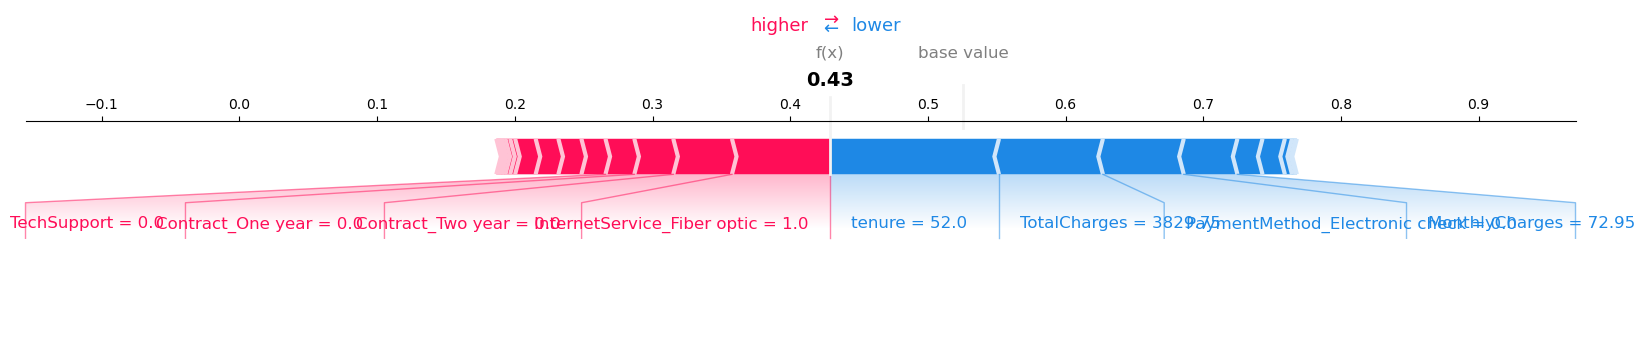

In [7]:
shap.force_plot(
    explainer.expected_value[1],  # expected value for class 1
    shap_values[0][:, 1],         # SHAP values for first sample, class 1
    X_test.iloc[0, :],            # feature values of the first sample
    matplotlib=True
)

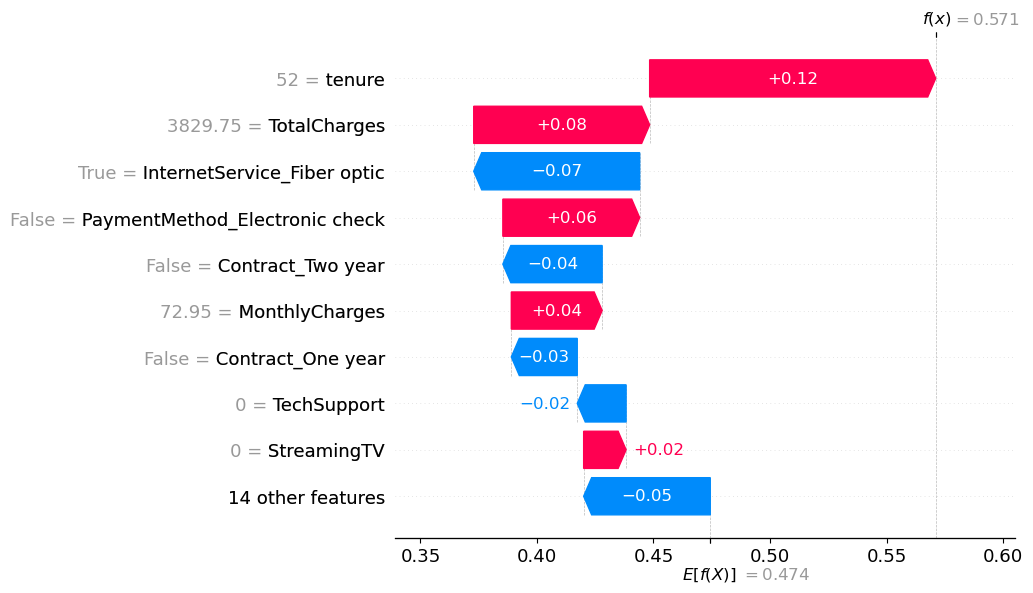

In [8]:
shap.waterfall_plot(shap.Explanation(
    values=shap_values[0][:, 0],      # SHAP values for first sample, class 0
    base_values=explainer.expected_value[0],  # expected value for class 0
    data=X_test.iloc[0, :]            # feature values of the first sample
))

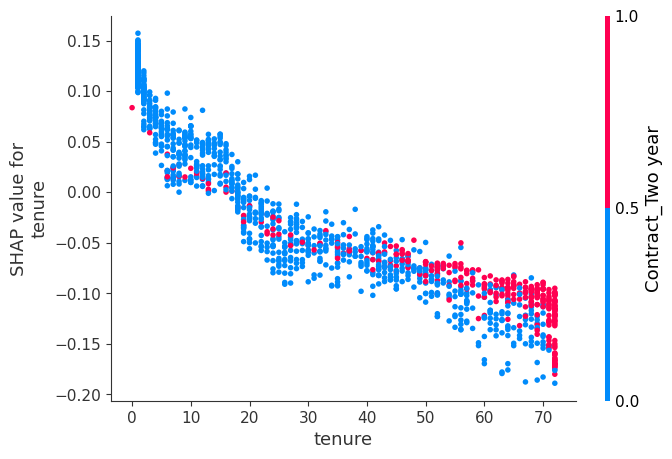

In [9]:
import shap
import numpy as np
import pandas as pd

# For class 1 (positive class)
shap_class1 = shap_values[:, :, 1]  # shape: num_samples x num_features

# Compute SHAP interaction matrix
interaction_values = np.abs(shap_class1).T @ np.abs(shap_class1)  # rough interaction measure
np.fill_diagonal(interaction_values, 0)  # ignore self

# Convert to DataFrame for easier lookup
shap_interaction_df = pd.DataFrame(interaction_values, index=X_test.columns, columns=X_test.columns)

# Feature of interest
feature_of_interest = 'tenure'

# Pick the feature with highest interaction for coloring
interaction_feature = shap_interaction_df[feature_of_interest].idxmax()

# Generate dependence plot
shap.dependence_plot(
    ind=feature_of_interest,
    shap_values=shap_class1,
    features=X_test,
    interaction_index=interaction_feature  # highly dependent feature for color
)


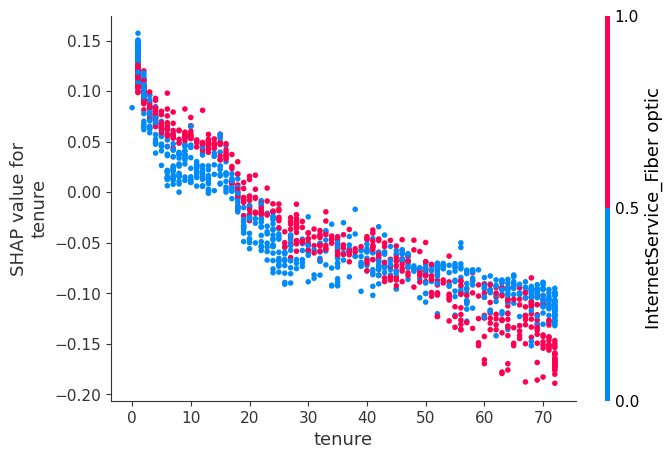

In [10]:
shap_class1 = shap_values[:, :, 1]  # num_samples x num_features for class 1

# Dependence plot for a feature, e.g., 'tenure'
shap.dependence_plot(
    ind='tenure',         # feature name or index
    shap_values=shap_class1,
    features=X_test,
    interaction_index='InternetService_Fiber optic'  # can also choose another feature for color
)